# GLM Tuning-Variable Analysis (LEC)

Split from `LEC_sploratory_analysis_with_glm_and_population.ipynb`. This notebook fits a per-neuron OLS GLM to ask **which task variables drive LEC firing rates**: place, head direction, goal progress, speed, acceleration, and time/distance from/to the next reward.

Backed by [`glm_analysis_v2.py`](glm_analysis_v2.py) — a sibling of `glm_analysis.py` that uses a **no-intercept, keep-all-bins** parameterization (see method note below).


## Method: per-regressor significance via permutation F-test

For each neuron, we fit a full OLS model

$$y_t = X_t \beta + \varepsilon_t$$

where $X$ is a 127-column design matrix of one-hot encoded task variables (no intercept — see note below). The variables are: **place** (21 bins, one per node), **head direction** (36 ten-degree bins), **goal progress** (10 equal-width bins), and **speed, acceleration, time-from-reward, time-to-reward, distance-from-reward, distance-to-reward** (10 decile bins each).

To test whether a *regressor group* (e.g., all 21 place columns) significantly explains firing-rate variance, we use the classic **nested F-test**:

$$F = \frac{(\mathrm{RSS}_{\mathrm{reduced}} - \mathrm{RSS}_{\mathrm{full}}) / df_{\mathrm{num}}}{\mathrm{RSS}_{\mathrm{full}} / df_{\mathrm{resid}}}$$

where $\mathrm{RSS}_{\mathrm{reduced}}$ is the residual sum of squares for the model with that regressor group's columns dropped, $df_{\mathrm{num}}$ is the number of columns in the group (e.g., 21 for place), and $df_{\mathrm{resid}} = T - n_{\mathrm{params}}$.

The **null distribution of F** is obtained by *circularly shifting the firing rate* by a random offset 100 times, re-fitting both full and reduced models, and computing the F-stat for each shift. A neuron is classified as significantly tuned to a regressor group if its observed F exceeds the **95th percentile** of the permutation distribution.

The **direction of tuning** (+1 / −1) for *ordered* regressors (GP, speed, acceleration, time-/distance-from/to-reward) is the sign of the linear slope fit through the bin-by-bin beta profile — capturing whether the neuron ramps up or down across the variable's range. For *unordered* regressors (place, head direction), we report the sign of the mean beta as a coarse summary.

**Note on the design matrix**: we use **no intercept** and **keep all bins** of each variable (rather than the conventional "drop one reference bin per variable"). This is rank-deficient by 8 (each variable's one-hot block sums to 1, creating linear dependencies between blocks); `np.linalg.lstsq` returns the minimum-norm solution. The F-test is **invariant to this parameterization** — the column space of $X$ is unchanged, so $\mathrm{RSS}_{\mathrm{full}}$ and $\mathrm{RSS}_{\mathrm{reduced}}$ are unchanged. Individual betas now represent absolute firing-rate contributions per bin rather than differences vs a reference bin.


In [11]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import os, pickle
from tqdm import tqdm


In [12]:
Data_folder="../data/processed_data"
figures_folder="../data/figures"
neuron_folder = f"{Data_folder}/neuron_raw_mingyutest"
trialtimes_folder = f"{Data_folder}/trialtimes_raw_mingyutest"
tracking_folder = f"{Data_folder}/processed"


In [13]:
import pickle
import os

# Define the folder where the processed data is saved
processed_data_folder = "../data/processed_data"

# Load the main data dictionary
with open(os.path.join(processed_data_folder, 'data_dic_for_yaren.pkl'), 'rb') as f:
    data_dic = pickle.load(f)

# Load the normalized neurons dictionary
with open(os.path.join(processed_data_folder, 'norm_neurons_dic.pkl'), 'rb') as f:
    norm_neurons_dic = pickle.load(f)

# Load the session indices dictionary
with open(os.path.join(processed_data_folder, 'session_inds_dic.pkl'), 'rb') as f:
    session_inds_dic = pickle.load(f)

# Load the tasks dictionary
with open(os.path.join(processed_data_folder, 'tasks_dic.pkl'), 'rb') as f:
    tasks_dic = pickle.load(f)

print(f"Loaded data dictionaries from {processed_data_folder}")


Loaded data dictionaries from ../data/processed_data


In [14]:
all_files = os.listdir(neuron_folder)
neuron_files = [f for f in all_files if f.startswith('Neuron_raw_') and f.endswith('.npy')]

mouse_recdays_ = []
for f in neuron_files:
    # Remove prefix 'Neuron_raw_' and suffix '.npy'
    stripped_name = f[len('Neuron_raw_'):-len('.npy')]
    # Split by '_' and rejoin all parts except the last one (session number)
    mouse_recday = '_'.join(stripped_name.split('_')[:-1])
    mouse_recdays_.append(mouse_recday)

# Find the unique mouse_recday identifiers
mouse_recdays = np.unique(mouse_recdays_)

# Filter out identifiers containing '_sb'
unique_mouse_recdays = [recday for recday in mouse_recdays if '_sb' not in recday]

print("Unique mouse_recday identifiers (without '_sb'):")
print(unique_mouse_recdays)

# Assign the first unique identifier to mouse_recday for later use
if len(unique_mouse_recdays) > 0:
    mouse_recday = unique_mouse_recdays[0]

mouse_recdays = unique_mouse_recdays


Unique mouse_recday identifiers (without '_sb'):
[np.str_('ah08_20250613_20250615'), np.str_('ah08_20250616_20250617'), np.str_('ah08_20250618_20250619'), np.str_('ah08_20250620_20250623'), np.str_('ah08_20250624_20250625'), np.str_('ah10_20250613_20250615'), np.str_('ah10_20250616_20250617'), np.str_('ah10_20250618_20250619'), np.str_('ah10_20250620_20250623'), np.str_('ah10_20250624_20250625'), np.str_('ly05_20250613_20250615'), np.str_('ly05_20250616_20250617'), np.str_('ly05_20250618_20250619'), np.str_('ly05_20250624_20250625'), np.str_('ly06_20250613_20250615'), np.str_('ly06_20250616_20250617'), np.str_('ly06_20250618_20250619'), np.str_('ly06_20250620_20250623'), np.str_('ly06_20250624_20250625'), np.str_('ly07_20250613_20250615'), np.str_('ly07_20250616_20250617'), np.str_('ly07_20250618_20250619'), np.str_('ly07_20250620_20250623'), np.str_('ly07_20250624_20250625')]


## Fit GLM

In [ ]:
from importlib import reload
import glm_analysis_v2
reload(glm_analysis_v2)

from glm_analysis_v2 import run_glm_analysis

GLM_results, Permutation_results = run_glm_analysis(mouse_recdays, data_dic)

Processing recording days:   0%|          | 0/24 [00:00<?, ?it/s]


ah08_20250613_20250615
  Design matrix: 16097 rows × 127 cols (regressors: ['place', 'head_direction', 'goal_progress', 'speed', 'acceleration', 'time_from_reward', 'time_to_reward', 'distance_from_reward', 'distance_to_reward'])



# F= (how much worse the reduced model is)  / (how noisy the full model already was)


RSS_full = how badly the full model fits
RSS_reduced = how badly the model fits without goal progress

sign for GP, speed (ordered variables): fit a line through betas, report slope sign

less interpretable for space. not ordered, so just report the mean beta sign (probably get rid of this bit)

## Per-regressor tuning summary

ah08_20250613_20250615: tuning array shape = (151, 9)
ah08_20250616_20250617: tuning array shape = (164, 9)
ah08_20250618_20250619: tuning array shape = (183, 9)
ah08_20250620_20250623: tuning array shape = (108, 9)
ah08_20250624_20250625: tuning array shape = (186, 9)
ah10_20250613_20250615: tuning array shape = (139, 9)
ah10_20250616_20250617: tuning array shape = (154, 9)
ah10_20250618_20250619: tuning array shape = (162, 9)
ah10_20250620_20250623: tuning array shape = (153, 9)
ah10_20250624_20250625: tuning array shape = (164, 9)
ly05_20250613_20250615: tuning array shape = (117, 9)
ly05_20250616_20250617: tuning array shape = (116, 9)
ly05_20250618_20250619: tuning array shape = (91, 9)
ly05_20250624_20250625: tuning array shape = (74, 9)
ly06_20250613_20250615: tuning array shape = (68, 9)
ly06_20250616_20250617: tuning array shape = (79, 9)
ly06_20250618_20250619: tuning array shape = (76, 9)
ly06_20250620_20250623: tuning array shape = (67, 9)
ly06_20250624_20250625: tuning arr

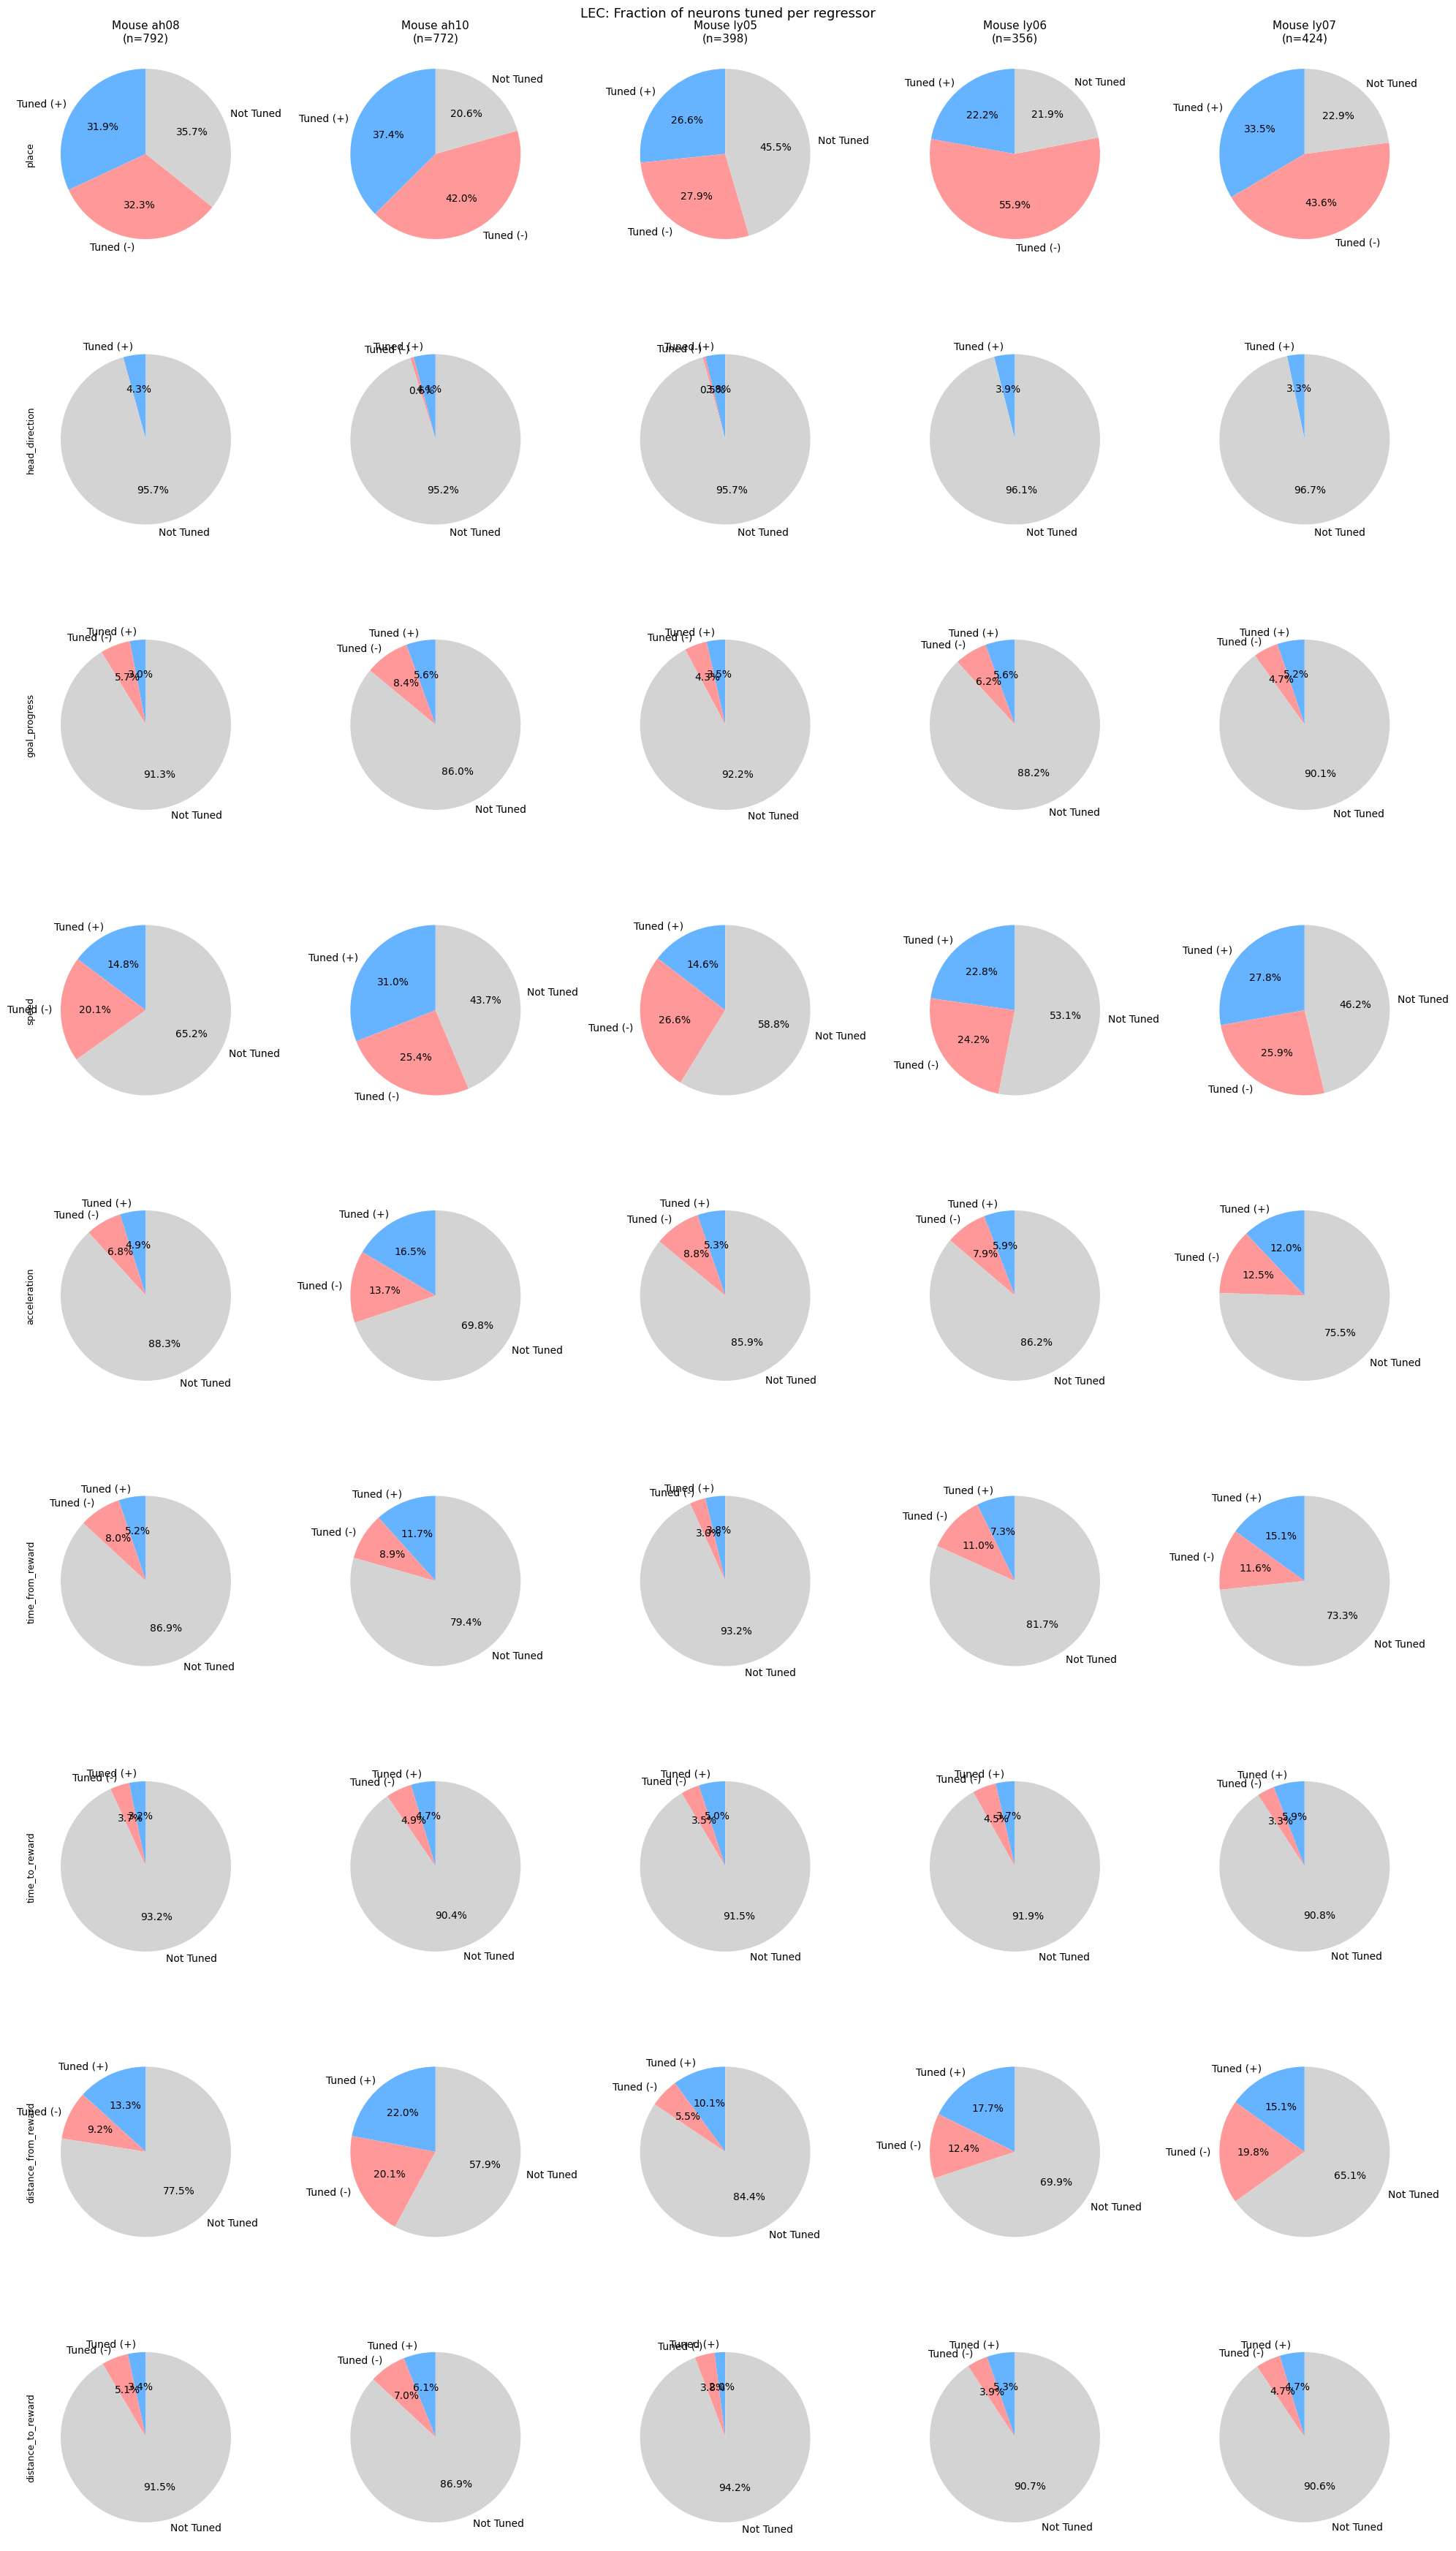

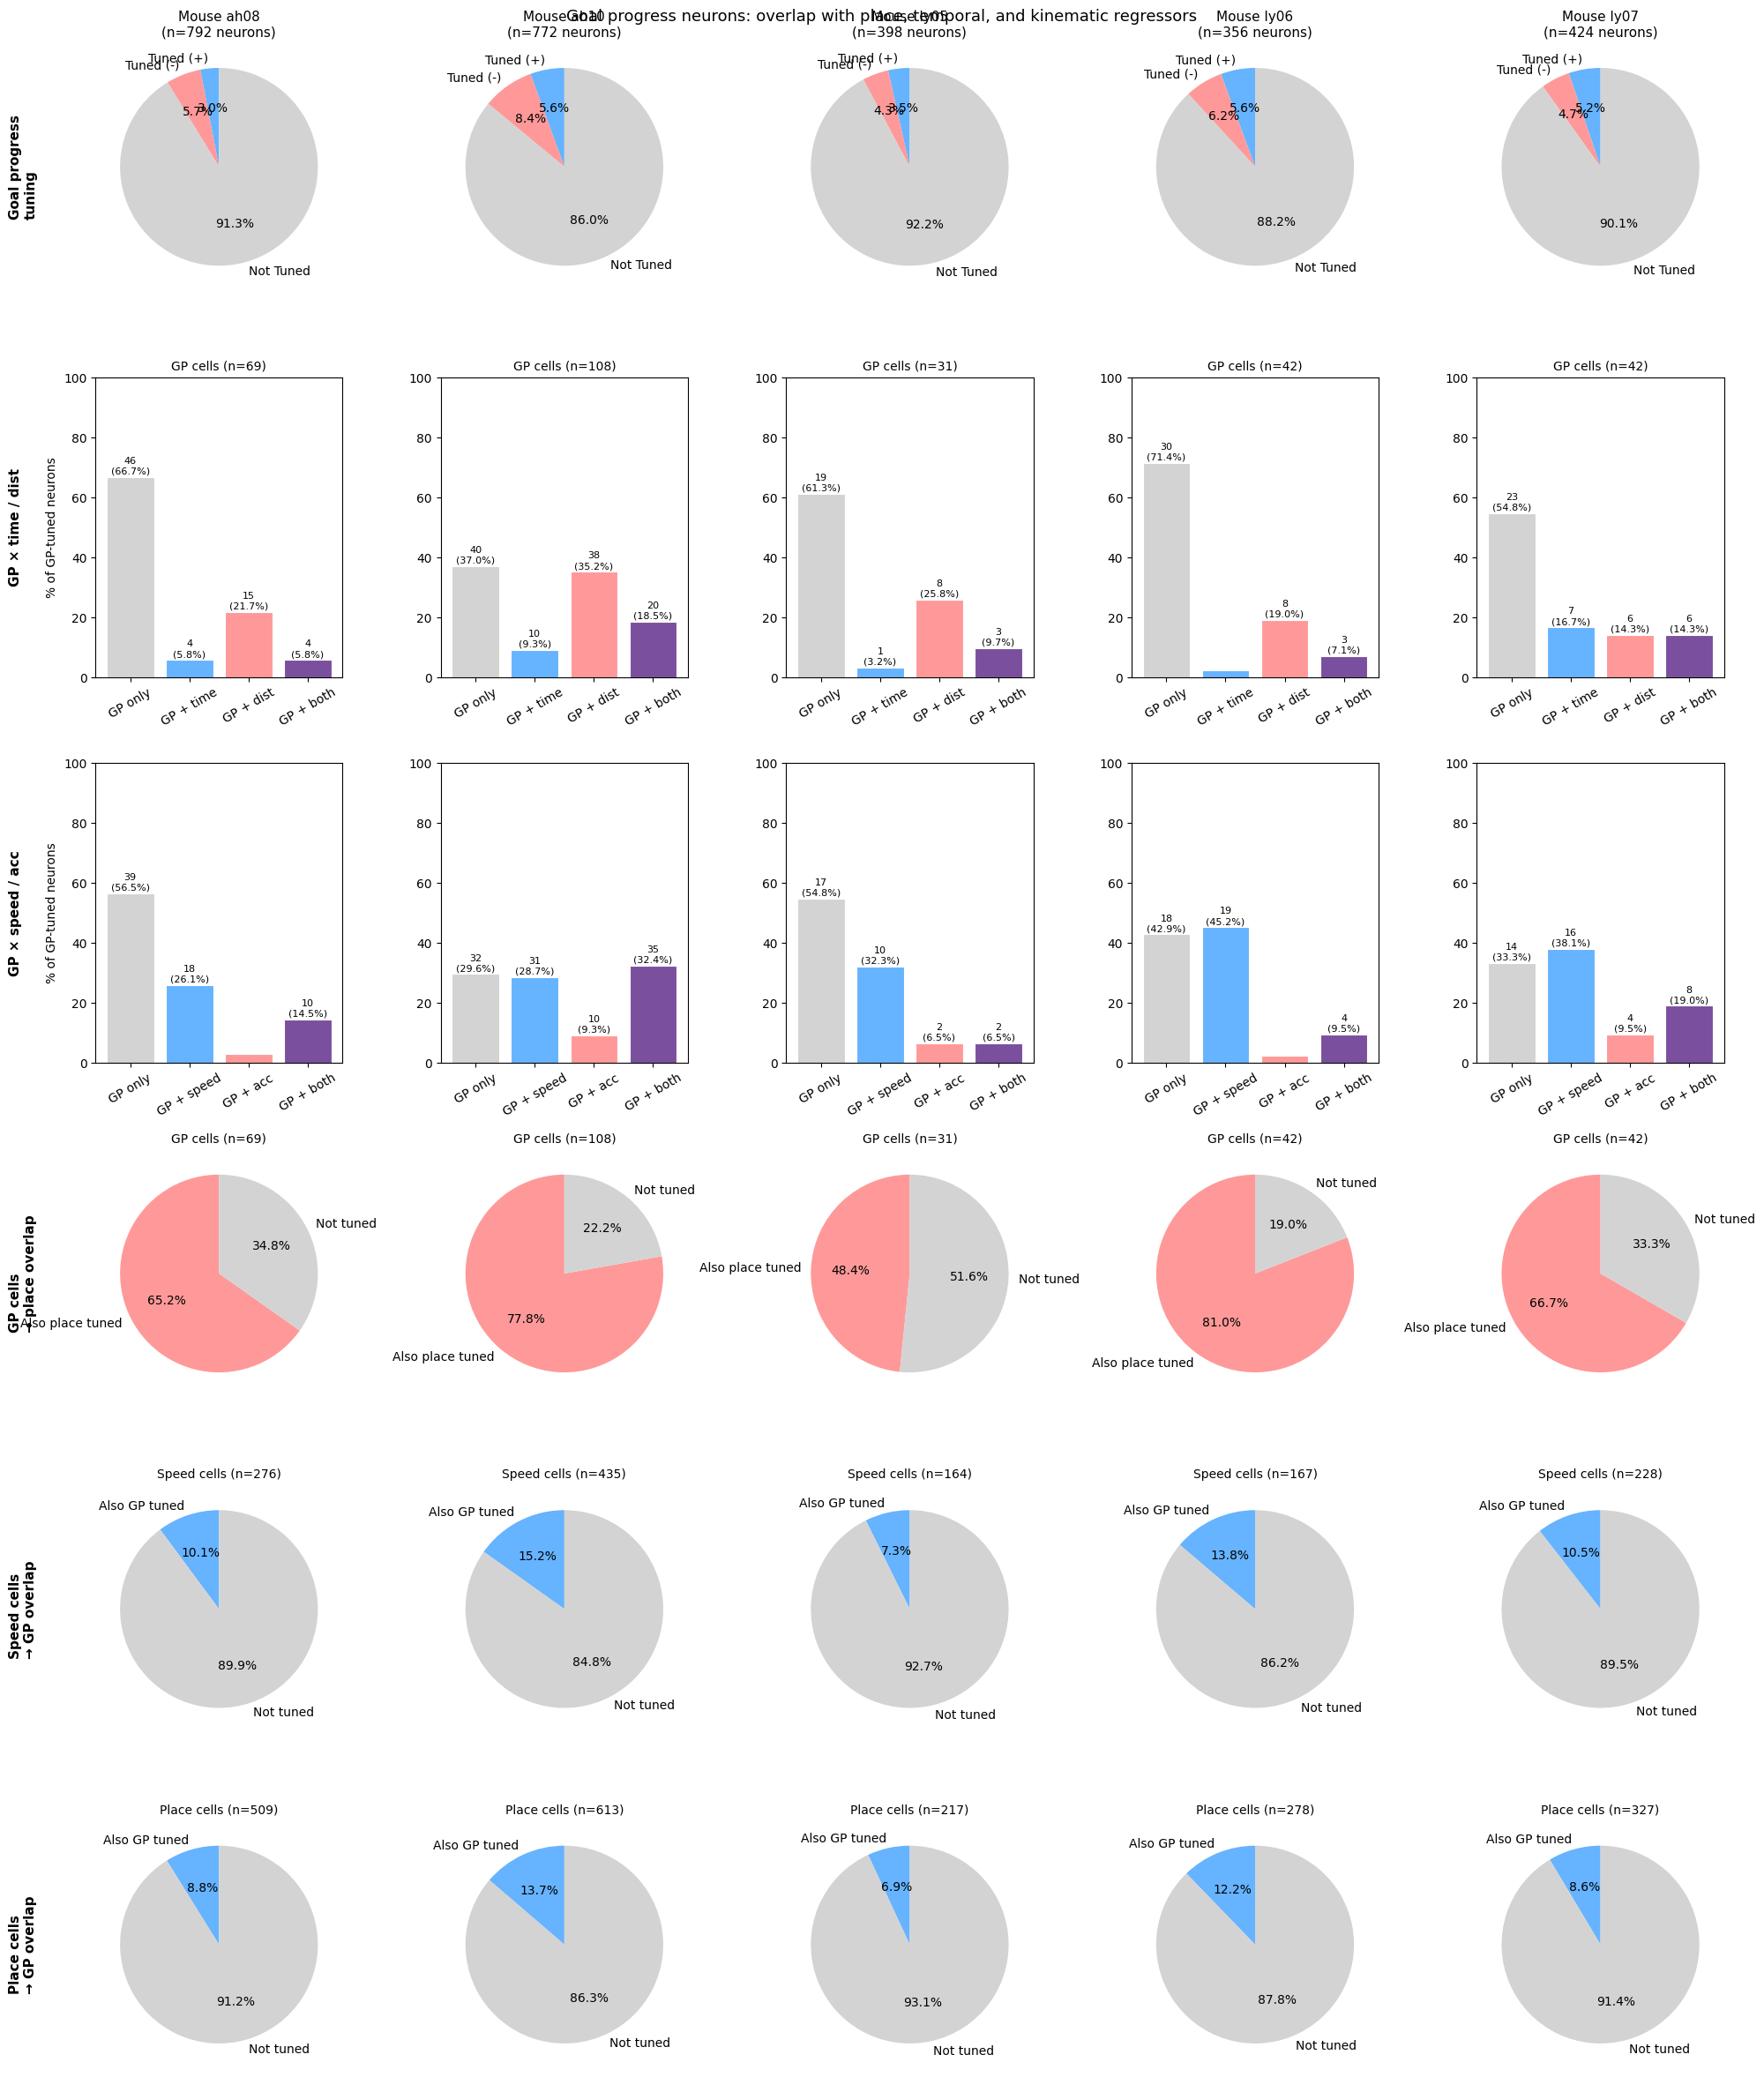


Tuning Summary:

Mouse ah08 (n=792):
  place: 509/792 (64.3%)  [253+ / 256-]
  head_direction: 34/792 (4.3%)  [34+ / 0-]
  goal_progress: 69/792 (8.7%)  [24+ / 45-]
  speed: 276/792 (34.8%)  [117+ / 159-]
  acceleration: 93/792 (11.7%)  [39+ / 54-]
  time_from_reward: 104/792 (13.1%)  [41+ / 63-]
  time_to_reward: 54/792 (6.8%)  [25+ / 29-]
  distance_from_reward: 178/792 (22.5%)  [105+ / 73-]
  distance_to_reward: 67/792 (8.5%)  [27+ / 40-]

Mouse ah10 (n=772):
  place: 613/772 (79.4%)  [289+ / 324-]
  head_direction: 37/772 (4.8%)  [32+ / 5-]
  goal_progress: 108/772 (14.0%)  [43+ / 65-]
  speed: 435/772 (56.3%)  [239+ / 196-]
  acceleration: 233/772 (30.2%)  [127+ / 106-]
  time_from_reward: 159/772 (20.6%)  [90+ / 69-]
  time_to_reward: 74/772 (9.6%)  [36+ / 38-]
  distance_from_reward: 325/772 (42.1%)  [170+ / 155-]
  distance_to_reward: 101/772 (13.1%)  [47+ / 54-]

Mouse ly05 (n=398):
  place: 217/398 (54.5%)  [106+ / 111-]
  head_direction: 17/398 (4.3%)  [15+ / 2-]
  goal_pro

In [ ]:
from glm_analysis_v2 import (
    compute_tuning_arrays,
    group_tuning_by_mouse,
    plot_tuning_piecharts,
    plot_gp_overlap,
    print_tuning_summary,
)

tuned_dict = compute_tuning_arrays(GLM_results, Permutation_results)
mouse_tuning_concat = group_tuning_by_mouse(tuned_dict)

plot_tuning_piecharts(mouse_tuning_concat)
plot_gp_overlap(mouse_tuning_concat)
print_tuning_summary(mouse_tuning_concat)

In [ ]:
example_neuron_tunings = tuned_dict['ly07_20250616_20250617'][20]
regressor_group_ids = ['place',
'head direction',
'goal progress',
'speed' ,
'acceleration',
'time-from-reward',
'time-to-reward',
'distance-from-reward',
'distance-to-reward']

for i, j in zip(regressor_group_ids, example_neuron_tunings):
    print(f"{i}: {j}")

place: 1
head direction: 0
goal progress: 0
speed: 0
acceleration: 1
time-from-reward: 1
time-to-reward: 1
distance-from-reward: -1
distance-to-reward: 0


## No-lookahead variant: GLM without `time_to_reward` and `distance_to_reward`

`time_to_reward` and `distance_to_reward` are **forward-looking** — they encode information about a reward that hasn't happened yet. That makes their relationship with `goal_progress` somewhat tautological: if the animal effectively "knows" how far the next reward is, that's almost by construction what goal-progress encodes.

Below we refit the GLM with these two regressors removed and re-run the same tuning analysis. If `goal_progress` tuning largely survives the removal, it suggests neurons encode progress from intrinsic cues (e.g., time/distance since *last* reward, place, head direction) rather than purely lookahead. If GP tuning collapses, much of the apparent signal was driven by the forward-looking variables.

In [ ]:
# Variant without forward-looking regressors (time_to_reward, distance_to_reward).
# Same pipeline; only the design-matrix subset changes.

reload(glm_analysis_v2)
from glm_analysis_v2 import (
    run_glm_analysis,
    compute_tuning_arrays,
    group_tuning_by_mouse,
    plot_tuning_piecharts,
    plot_gp_overlap,
    print_tuning_summary,
)

included = [
    'place', 'head_direction', 'goal_progress',
    'speed', 'acceleration',
    'time_from_reward', 'distance_from_reward',
]

GLM_results_nl, Permutation_results_nl = run_glm_analysis(
    mouse_recdays, data_dic,
    regressors_to_include=included,
)

tuned_dict_nl = compute_tuning_arrays(
    GLM_results_nl, Permutation_results_nl,
    regressors_to_include=included,
)
mouse_tuning_concat_nl = group_tuning_by_mouse(tuned_dict_nl)

plot_tuning_piecharts(mouse_tuning_concat_nl, regressors_to_include=included)
plot_gp_overlap(mouse_tuning_concat_nl, regressors_to_include=included)
print_tuning_summary(mouse_tuning_concat_nl, regressors_to_include=included)

**Interpretation**: compare the pie charts above (all 9 regressors) vs below (7 regressors). If `goal_progress` tuning fractions drop dramatically when the lookahead variables are removed, the original GP signal was substantially driven by them. If GP fractions are stable, neurons are tuned to progress independent of the lookahead variables.